<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/Assignment_3_The_Causal_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])
print("Median:", np.median(driver_tips))
print("Mean:", np.mean(driver_tips))

Median: 0.7553316913699188
Mean: 2.7690587934081927


In [ ]:
n_bootstrap = 10000
bootstrapped_medians = np.zeros(n_bootstrap)
for i in range(n_bootstrap):
  resampe = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
  bootstrapped_medians[i] = np.median(resampe)
ci_lower, ci_upper = np.percentile(bootstrapped_medians, [2.5, 97.5])
print("95% Median Confidence Interval: (", ci_lower, ",", ci_upper, ")")

95% Median Confidence Interval: ( 0.2642554369019624 , 1.366359949751731 )


In [ ]:
np.random.seed(42)

control_data = np.random.normal(loc=35, scale=5,size=500)

treatment_data = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_dif = np.mean(control_data) - np.mean(treatment_data)

print("Control Group Mean:", np.mean(control_data),"minutes")
print("Treatment Group Mean:", np.mean(treatment_data),"minutes")
print("Observed Difference in Means (Control - Treatment):", observed_dif,"minutes")

Control Group Mean: 35.03418997294323 minutes
Treatment Group Mean: 32.76920784231749 minutes
Observed Difference in Means (Control - Treatment): 2.2649821306257394 minutes


In [ ]:
all_deliveries = np.concatenate([control_data, treatment_data])
n_perm = 5000
perm_diffs = np.zeros(n_perm)
for i in range(n_perm):
  shuffled = np.random.permutation(all_deliveries)
  pseudo_control = shuffled[:500]
  pseudo_treatment = shuffled[500:]
  perm_diffs[i] = np.mean(pseudo_control) - np.mean(pseudo_treatment)
p_value = np.mean(np.abs(perm_diffs) >= abs(observed_dif))


Empirical P-value: 0.0004


In [ ]:
df = pd.read_csv("swiftcart_loyalty.csv")
mean_sub = df[df["subscriber"] == 1]["post_spend"].mean()
mean_non = df[df["subscriber"] == 0]["post_spend"].mean()
sdo = mean_sub - mean_non
print("Mean Post Spend (Subscribers):", mean_sub)
print("Mean Post Spend (Non-Subscribers):", mean_non)
print("Naive SDO:", sdo)

Mean Post Spend (Subscribers): 74.04358604052543
Mean Post Spend (Non-Subscribers): 56.47291665600164
Naive SDO: 17.57066938452379


In [ ]:
from sklearn.linear_model import LogisticRegression
X = df[["pre_spend", "account_age", "support_tickets"]]
y = df["subscriber"]
logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)
df["propensity_score"] = logit.predict_proba(X)[:,1]

In [ ]:
from sklearn.neighbors import NearestNeighbors
treated = df[df["subscriber"] == 1].copy()
control = df[df["subscriber"] == 0].copy()
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])
distances, indices = nn.kneighbors(treated[["propensity_score"]])
matched_control = control.iloc[indices.flatten()].copy()
matched_control.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend,propensity_score
2313,0,57.466146,37,2,69.471180,0.546687
4749,0,51.467199,33,0,58.999521,0.548407
4488,0,63.217201,42,1,62.207131,0.683865
6738,0,94.031093,13,3,98.367349,0.779709
3022,0,43.828601,40,2,61.964309,0.397514


In [ ]:
ATT = (treated["post_spend"].values - matched_control["post_spend"].values).mean()
print("Average Treatment Effect (ATT):", ATT)

Average Treatment Effect (ATT): 9.913855182824864


In [ ]:
mean_sub = df[df["subscriber"] == 1]["post_spend"].mean()
mean_non = df[df["subscriber"] == 0]["post_spend"].mean()
SDO = mean_sub - mean_non
print("Naive SDO:", SDO)
print("ATT:", ATT)

Naive SDO: 17.57066938452379
ATT: 9.913855182824864


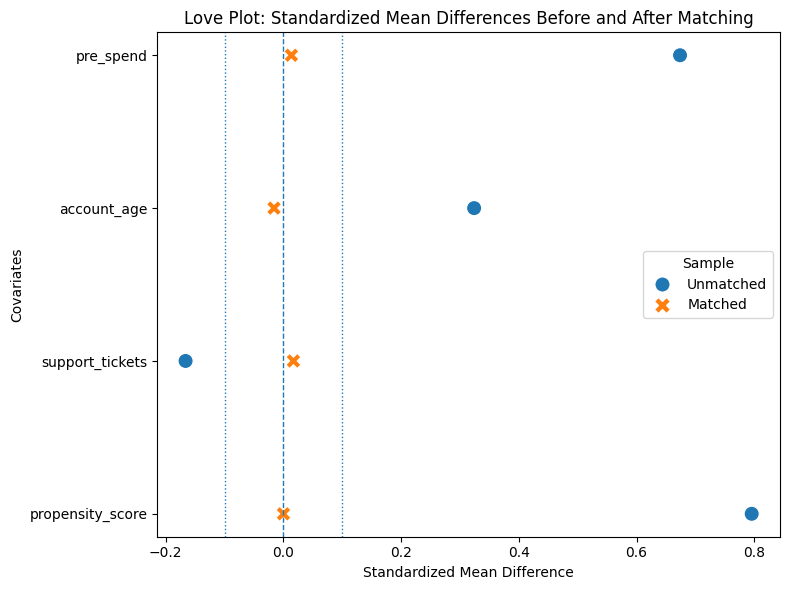

In [ ]:
treatment_col = "subscriber"
df_unmatched = df.copy()
df_matched = pd.concat([treated, matched_control], axis=0)
df_matched = df_matched.reset_index(drop=True)
# Select covariates automatically
covariates = [c for c in df_unmatched.columns if c not in [treatment_col, "post_spend"]]


def compute_smd(df, covariates, treatment_col):
    smd = {}

    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    for cov in covariates:
        mean_t = treated[cov].mean()
        mean_c = control[cov].mean()

        var_t = treated[cov].var()
        var_c = control[cov].var()

        pooled_sd = np.sqrt((var_t + var_c) / 2)

        smd[cov] = (mean_t - mean_c) / pooled_sd

    return pd.Series(smd)


# Compute SMDs
smd_unmatched = compute_smd(df_unmatched, covariates, treatment_col)
smd_matched = compute_smd(df_matched, covariates, treatment_col)

# Combine results
love_df = pd.DataFrame({
    "Covariate": covariates,
    "Unmatched": smd_unmatched.values,
    "Matched": smd_matched.values
})

love_df = love_df.melt(id_vars="Covariate", var_name="Group", value_name="SMD")

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=love_df,
    x="SMD",
    y="Covariate",
    hue="Group",
    style="Group",
    s=120
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(0.1, linestyle=":", linewidth=1)
plt.axvline(-0.1, linestyle=":", linewidth=1)

plt.title("Love Plot: Standardized Mean Differences Before and After Matching")
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariates")

plt.legend(title="Sample")
plt.tight_layout()

plt.show()